# Mô Phỏng Máy Hút Bụi (Vacuum Cleaner Agent) – Simulated Annealing (Không che khuất lịch sử di chuyển)

**Quy ước hình ảnh:**
- **Máy hút bụi (Roomba):** Được vẽ dưới dạng khối tròn màu xanh tối (`#2C3E50`) viền xanh ngọc (`#1ABC9C`) tích hợp nút bấm LED nguồn màu xanh lá.
- **Bụi bẩn:** Thể hiện bằng các hạt chấm nhỏ màu vàng cát tụ lại thành cụm bụi tự nhiên trên nền vàng nhạt.
- **Tường/Vật cản:** Được vẽ dưới dạng khối gạch có vân gạch chéo đỏ nâu (`#A93226`) thay thế các chữ số thô cứng.
- **Không hiển thị số:** Các số `0`, `1`, `2` đã được lược bỏ hoàn toàn để giao diện trực quan hoàn chỉnh nhất.

**Chiến lược Simulated Annealing:**
- Thuật toán duy trì **1 đường đi duy nhất** (single path) thay vì k chùm tia như Local Beam Search.
- Tại mỗi bước tìm kiếm, sinh ngẫu nhiên 1 trạng thái kế tiếp (láng giềng) từ trạng thái hiện tại.
- **Nếu trạng thái kế tiếp tốt hơn** (ΔE <= 0, tức gần bụi hơn): luôn chấp nhận.
- **Nếu trạng thái kế tiếp tệ hơn** (ΔE > 0): chấp nhận với xác suất $e^{-\Delta E / T}$.
- **Nhiệt độ T** bắt đầu cao (cho phép khám phá tự do, thoát cực tiểu cục bộ) và giảm dần theo hệ số làm lạnh `cooling_rate`.
- **Heuristic** $h(n)$: khoảng cách Manhattan từ vị trí hiện tại đến ô bụi gần nhất.

**Chiến lược từng bước:**
- Từng bước di chuyển sẽ được render thành một bức ảnh riêng biệt giúp người xem dễ dàng cuộn chuột và xem lại toàn bộ lịch sử hành động (không bị hàm `clear_output` xóa mất).

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

Ma trận ban đầu (vị trí máy: (2, 4)):
[[0 2 1 0 0 0 0]
 [1 2 0 0 1 0 1]
 [0 0 0 1 0 2 0]
 [1 0 1 1 2 1 0]
 [0 0 0 1 0 1 1]]
Tổng bụi: 12 ô


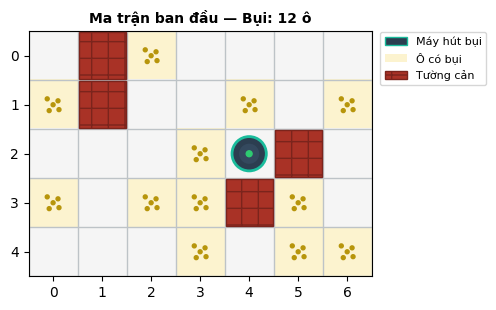

In [2]:
# ── Cấu hình ──
ROWS      = 5
COLS      = 7
WALL_PROB = 0.15
DUST_PROB = 0.35
MAX_STEPS = 300

# ── Tạo môi trường ngẫu nhiên ──
def create_env(rows, cols, wall_prob, dust_prob):
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            v = random.random()
            if v < wall_prob:
                grid[r][c] = 2
            elif v < wall_prob + dust_prob:
                grid[r][c] = 1
    free = [(r, c) for r in range(rows) for c in range(cols) if grid[r][c] != 2]
    pos = random.choice(free)
    return grid, pos

# ── Vẽ ma trận ──
def draw_grid(grid, pos, title):
    rows, cols = grid.shape
    fig, ax = plt.subplots(figsize=(cols * 0.75, rows * 0.75))

    # Colormap: 0=sạch (xám nhạt), 1=bụi (vàng nhạt), 2=tường (xám)
    cmap = ListedColormap(['#F5F5F5', '#FCF3CF', '#EAEDED'])
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)

    for r in range(rows):
        for c in range(cols):
            if (r, c) == pos:
                # Vẽ máy hút bụi kiểu Roomba tròn hiện đại
                # Vỏ ngoài máy
                ax.add_patch(mpatches.Circle((c, r), 0.35, facecolor='#2C3E50', edgecolor='#1ABC9C', linewidth=2, zorder=10))
                # Mặt trong
                ax.add_patch(mpatches.Circle((c, r), 0.22, facecolor='#34495E', edgecolor='#2C3E50', linewidth=1, zorder=11))
                # Đèn LED trạng thái hoạt động (màu xanh lá)
                ax.add_patch(mpatches.Circle((c, r), 0.06, color='#2ECC71', zorder=12))
            elif grid[r][c] == 1:
                # Vẽ bụi dưới dạng cụm hạt bụi nhỏ (5 chấm nhỏ tự nhiên)
                dots = [(-0.12, -0.12), (0.12, 0.1), (-0.08, 0.12), (0.1, -0.08), (0.0, 0.0)]
                for dx, dy in dots:
                    ax.add_patch(mpatches.Circle((c + dx, r + dy), 0.04, color='#B7950B', zorder=5))
            elif grid[r][c] == 2:
                # Vẽ tường cản dạng gạch xếp đơn giản
                rect = mpatches.Rectangle((c-0.48, r-0.48), 0.96, 0.96, facecolor='#A93226', edgecolor='#7B241C', hatch='|-', zorder=4)
                ax.add_patch(rect)

    # Cấu hình hệ trục và chia ô
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels(np.arange(cols))
    ax.set_yticklabels(np.arange(rows))
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='#BDC3C7', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)

    legend = [
        mpatches.Patch(facecolor='#2C3E50', edgecolor='#1ABC9C', label='Máy hút bụi'),
        mpatches.Patch(facecolor='#FCF3CF', label='Ô có bụi'),
        mpatches.Patch(facecolor='#A93226', edgecolor='#7B241C', hatch='|-', label='Tường cản')
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.35, 1.02), fontsize=8)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

grid, start = create_env(ROWS, COLS, WALL_PROB, DUST_PROB)
total_dust = int(np.sum(grid == 1))

print(f"Ma trận ban đầu (vị trí máy: {start}):")
print(grid)
print(f"Tổng bụi: {total_dust} ô")
draw_grid(grid, start, f"Ma trận ban đầu — Bụi: {total_dust} ô")

In [3]:
# ── Agent (Simulated Annealing) ──
MOVES = {'UP': (-1,0), 'DOWN': (1,0), 'LEFT': (0,-1), 'RIGHT': (0,1)}

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def _path_to_moves(path):
    move_path = []
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i+1]
        dr, dc = r2 - r1, c2 - c1
        for d, (mdr, mdc) in MOVES.items():
            if mdr == dr and mdc == dc:
                move_path.append((d, dr, dc))
                break
    return move_path

def simulated_annealing_find_nearest_dust(grid, start_pos, T0=2.0, cooling_rate=0.95):
    """
    Tìm đường đi đến ô bụi gần nhất bằng thuật toán Simulated Annealing.

    Thuật toán:
    - Duy trì 1 đường đi duy nhất (path) từ start_pos.
    - Tại mỗi bước, chọn ngẫu nhiên 1 ô láng giềng hợp lệ (chưa thăm trong path).
    - ΔE = h(láng giềng) - h(hiện tại), với h = khoảng cách Manhattan đến bụi mục tiêu.
    - Nếu ΔE <= 0: luôn chấp nhận (bước tốt hơn hoặc bằng).
    - Nếu ΔE > 0:  chấp nhận với xác suất exp(-ΔE / T).
    - Nhiệt độ T giảm dần: T = T * cooling_rate sau mỗi bước.
    """
    start_pos = tuple(start_pos)
    rows, cols = grid.shape
    dust_cells = [(r, c) for r in range(rows) for c in range(cols) if grid[r, c] == 1]
    if not dust_cells:
        return None, None

    # Tìm ô bụi gần nhất làm đích
    best_target = min(dust_cells, key=lambda d: manhattan(start_pos, d))
    max_steps_search = rows * cols * 3

    def _sa_search(target):
        # Chạy tối đa 30 lần thử để tìm được đường đi vì thuật toán có tính ngẫu nhiên
        for trial in range(30):
            path = [start_pos]
            visited_in_path = {start_pos}
            T = T0
            for _ in range(max_steps_search):
                curr = path[-1]
                if curr == target:
                    return _path_to_moves(path), target

                neighbors = []
                for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nr, nc = curr[0] + dr, curr[1] + dc
                    if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] != 2 and (nr, nc) not in visited_in_path:
                        neighbors.append((nr, nc))

                if not neighbors:
                    if len(path) > 1:
                        removed = path.pop()
                        visited_in_path.discard(removed)
                    else:
                        break
                    continue

                next_pos = random.choice(neighbors)
                current_energy = manhattan(curr, target)
                next_energy = manhattan(next_pos, target)
                delta_E = next_energy - current_energy

                T_eff = max(T, 1e-6)
                if delta_E <= 0 or random.random() < math.exp(-delta_E / T_eff):
                    path.append(next_pos)
                    visited_in_path.add(next_pos)
                    if next_pos == target:
                        return _path_to_moves(path), target

                T *= cooling_rate
        return None, None

    # Thử tìm đường đi tới đích gần nhất trước
    result = _sa_search(best_target)
    if result[0] is not None:
        return result

    # Nếu không tìm thấy, thử các ô bụi khác
    for target in dust_cells:
        if target == best_target:
            continue
        result = _sa_search(target)
        if result[0] is not None:
            return result

    return None, None

def run_agent(grid_in, start, max_steps):
    grid = grid_in.copy()
    rows, cols = grid.shape
    pos = list(start)
    history = set()
    steps = 0
    cleaned = 0

    # Hiển thị vị trí bắt đầu
    draw_grid(grid, pos=tuple(pos), title=f'Bắt đầu tại {tuple(pos)}')

    while steps < max_steps:
        r, c = pos

        # Hút bụi tại ô hiện tại nếu có
        if grid[r][c] == 1:
            state = ((r, c), 'CLEAN')
            if state in history:
                return grid, steps, cleaned, 'THAT BAI', 'Lap lai hanh dong CLEAN tai ' + str((r, c))
            history.add(state)
            grid[r][c] = 0
            cleaned += 1
            steps += 1

            draw_grid(grid, pos=tuple(pos), title=f'Bước {steps}: Phát hiện bụi! Hút bụi tại {tuple(pos)} — Đã hút: {cleaned}/{total_dust}')

            if cleaned == total_dust:
                return grid, steps, cleaned, 'THANH CONG', 'Da hut sach toan bo bui'
            continue

        # Tìm đường đi đến ô bụi gần nhất bằng Simulated Annealing
        path, target = simulated_annealing_find_nearest_dust(grid, pos)
        if path is None or len(path) == 0:
            if cleaned == total_dust:
                return grid, steps, cleaned, 'THANH CONG', 'Da hut sach toan bo bui'
            return grid, steps, cleaned, 'THAT BAI', 'Khong tim thay duong di den bui'

        # Thực hiện bước đi đầu tiên trong đường đi tìm được
        direction, dr, dc = path[0]
        state = ((r, c), direction)
        if state in history:
            return grid, steps, cleaned, 'THAT BAI', f'Lap lai hanh dong {direction} tai {(r, c)}'
        history.add(state)

        pos = [r + dr, c + dc]
        steps += 1

        draw_grid(grid, pos=tuple(pos), title=f'Bước {steps}: Di chuyển {direction} → ({pos[0]}, {pos[1]})')

    return grid, steps, cleaned, 'THAT BAI', f'Vuot qua gioi han {max_steps} buoc'

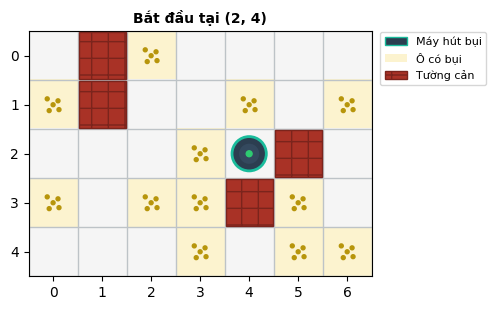

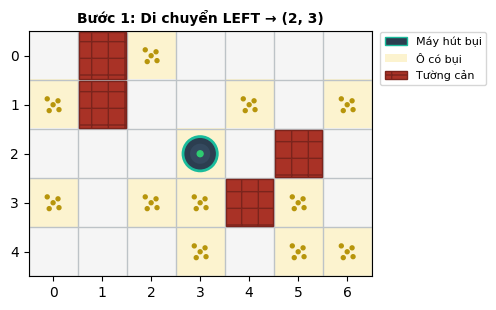

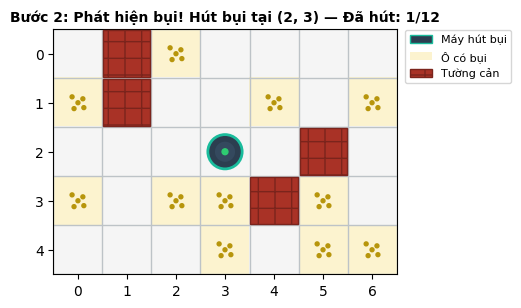

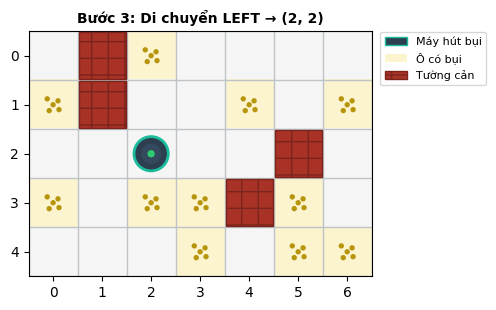

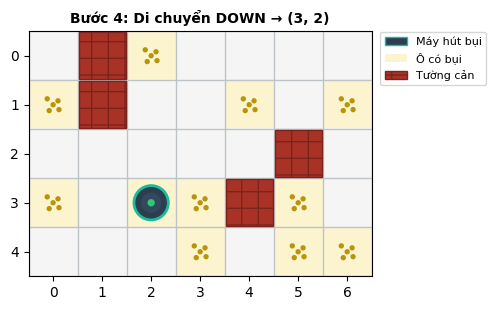

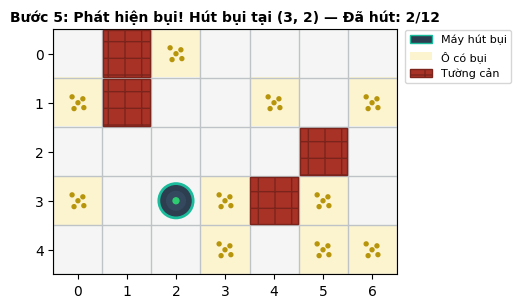

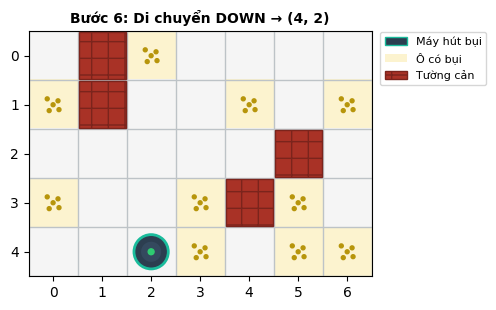

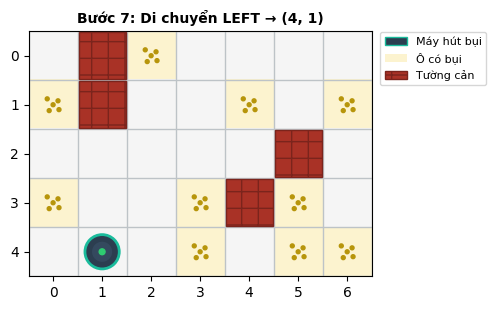

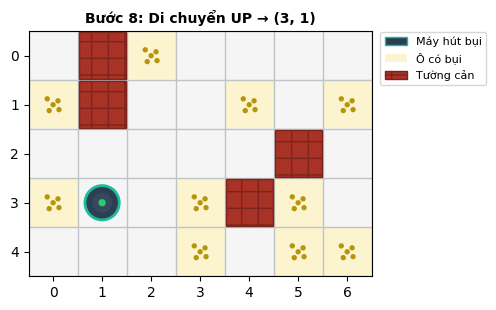

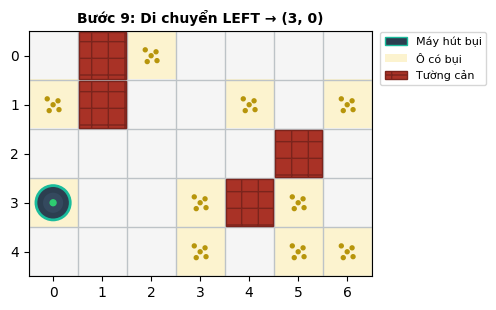

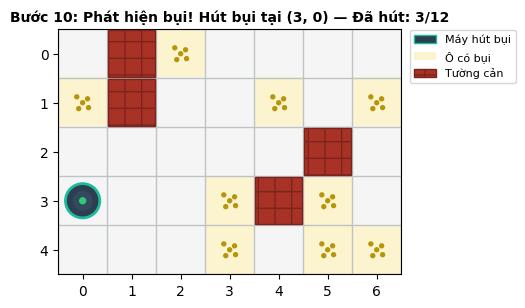

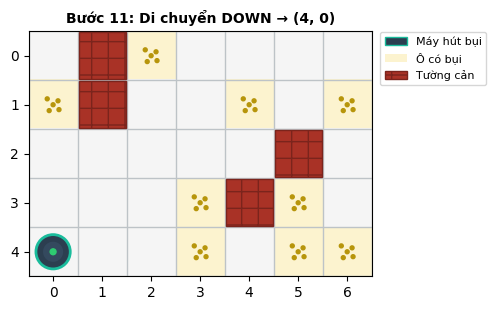

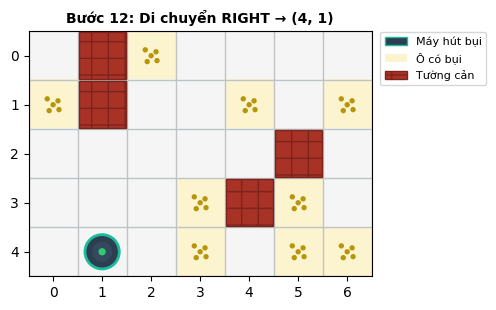

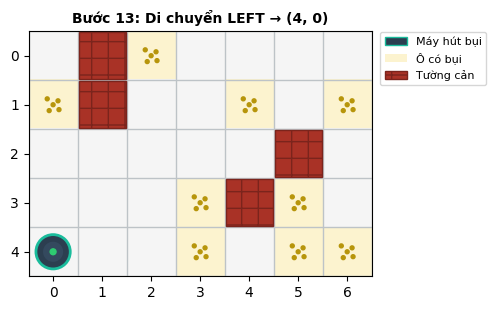

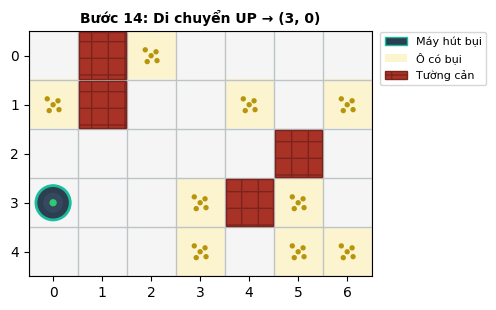

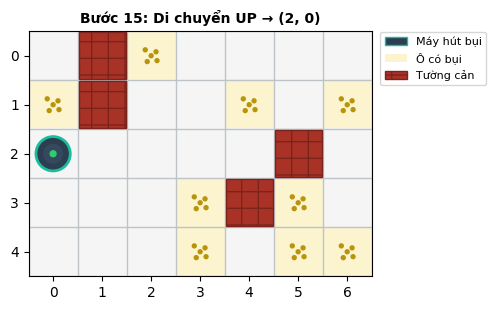

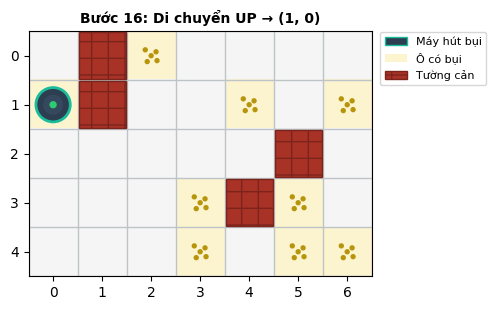

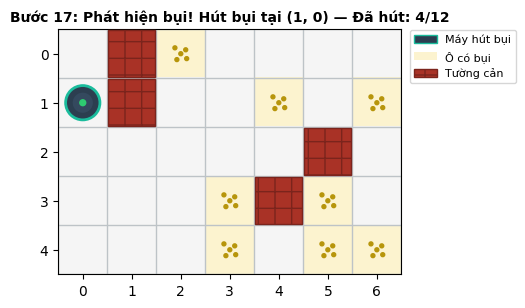

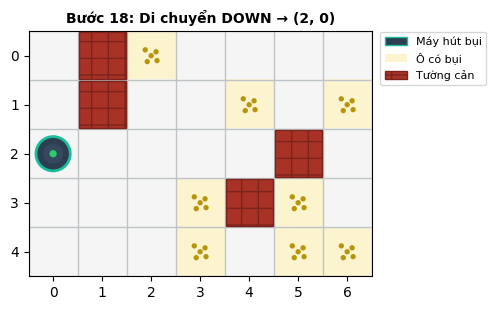

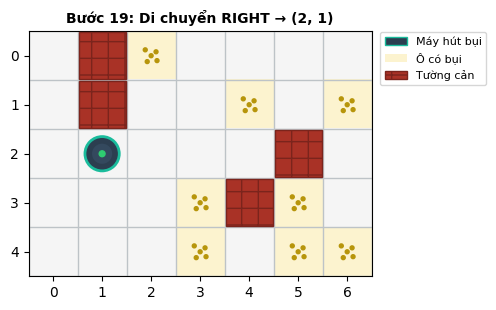

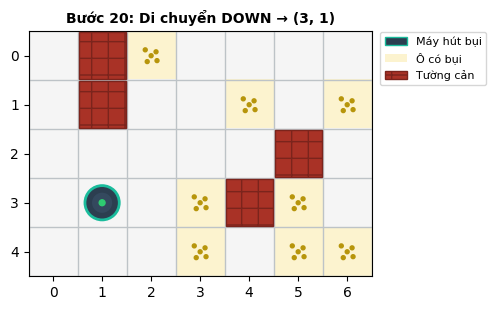

Ma tran sau khi chay:
[[0 2 1 0 0 0 0]
 [0 2 0 0 1 0 1]
 [0 0 0 0 0 2 0]
 [0 0 0 1 2 1 0]
 [0 0 0 1 0 1 1]]

So buoc di : 20
Bui da hut : 4 / 12 o
Trang thai : THAT BAI
Ly do      : Lap lai hanh dong LEFT tai (3, 1)


In [4]:
final_grid, steps, cleaned, status, reason = run_agent(grid, start, MAX_STEPS)

print("Ma tran sau khi chay:")
print(final_grid)
print()
print(f"So buoc di : {steps}")
print(f"Bui da hut : {cleaned} / {total_dust} o")
print(f"Trang thai : {status}")
print(f"Ly do      : {reason}")